# 12. Tensors & Embeddings
---

Every input to a neural network must be a number. Pixels are already numbers. But what about words? Categories? User IDs? Product names? These are **discrete** inputs — they have no natural numerical value.

This notebook covers how deep learning converts discrete things into numbers it can learn from — using **embeddings**.

## 12.1 The Problem: Discrete Inputs

Consider the word "cat". How do you represent it as a number?

### Attempt 1: Just use an integer
Assign each word an integer: cat=1, dog=2, elephant=3. The problem: this implies a false ordering. Is dog twice as "cat" as cat? Is elephant three times? The number carries no meaning.

### Attempt 2: One-hot encoding
This is the traditional ML approach (same as `pd.get_dummies` in pandas). Represent each word as a vector of zeros with a single 1 at its index:

```
Vocabulary: [cat, dog, elephant, ...]

cat      → [1, 0, 0, 0, 0, ... 0]   (50,000 dimensions)
dog      → [0, 1, 0, 0, 0, ... 0]
elephant → [0, 0, 1, 0, 0, ... 0]
```

This works, but has serious problems at scale:
- A vocabulary of 50,000 words → every word is a vector of length 50,000
- 99.998% of the vector is zeros — almost no information per dimension
- "king" and "queen" are as geometrically distant as "king" and "chair" — the encoding captures no semantic similarity
- For language models, the weight matrix connecting one-hot inputs to the first layer would be 50,000 × hidden_size — enormous

### Solution: Embeddings

An **embedding** maps each discrete token to a **dense, low-dimensional vector** that is learned during training:

```
cat      → [0.21, -0.45,  0.88,  0.12]   (4 dimensions — learned)
dog      → [0.19, -0.41,  0.85,  0.09]   (similar to cat!)
elephant → [-0.34, 0.71, -0.22,  0.55]   (different)
chair    → [-0.51, 0.12, -0.61, -0.34]   (very different)
```

After training, words with similar meaning end up with similar vectors — not because we told the model which words are similar, but because the model learned it from context. This is the fundamental insight behind Word2Vec, GloVe, and all modern language model embeddings.

### Connection to traditional ML
One-hot encoding is the standard approach in traditional ML for categorical variables — it's what `pd.get_dummies` and sklearn's `OneHotEncoder` produce. Embeddings are the deep learning upgrade: instead of fixed binary representations, each category gets a learned dense representation optimised for the task.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.manual_seed(42)

# Compare one-hot vs embedding memory and density
vocab_size = 50000
embed_dim  = 256

onehot_memory_mb  = (vocab_size * vocab_size * 4) / 1e6          # float32 matrix
embed_memory_mb   = (vocab_size * embed_dim  * 4) / 1e6

print("=== One-hot vs Embedding ===")
print(f"Vocabulary size: {vocab_size:,} words")
print()
print(f"One-hot representation:")
print(f"  Vector size per word: {vocab_size:,} dimensions")
print(f"  Zeros per vector:     {vocab_size-1:,} ({(vocab_size-1)/vocab_size:.4%})")
print(f"  Weight matrix size:   {vocab_size:,} × {vocab_size:,} = {onehot_memory_mb:,.0f} MB")
print()
print(f"Embedding representation (dim={embed_dim}):")
print(f"  Vector size per word: {embed_dim} dimensions")
print(f"  Zeros per vector:     ~0 (dense — all values informative)")
print(f"  Embedding table size: {vocab_size:,} × {embed_dim} = {embed_memory_mb:.0f} MB")
print(f"\n  Memory saving: {onehot_memory_mb/embed_memory_mb:.0f}x smaller")

=== One-hot vs Embedding ===
Vocabulary size: 50,000 words

One-hot representation:
  Vector size per word: 50,000 dimensions
  Zeros per vector:     49,999 (99.9980%)
  Weight matrix size:   50,000 × 50,000 = 10,000 MB

Embedding representation (dim=256):
  Vector size per word: 256 dimensions
  Zeros per vector:     ~0 (dense — all values informative)
  Embedding table size: 50,000 × 256 = 51 MB

  Memory saving: 195x smaller


## 12.2 How `nn.Embedding` Works

`nn.Embedding(vocab_size, embed_dim)` is simply a **lookup table** — a matrix of shape `(vocab_size × embed_dim)`. Each row corresponds to one token. When you pass in a token ID, it returns the corresponding row.

```
Embedding table  (shape: vocab_size × embed_dim)
┌────────────────────────────────────┐
│ token 0: [ 0.12, -0.45,  0.88 ]   │
│ token 1: [ 0.67,  0.23, -0.11 ]   │
│ token 2: [-0.34,  0.91,  0.05 ]   │  ← input token_id=2 → return this row
│ token 3: [ 0.88, -0.12,  0.44 ]   │
│ ...                                │
└────────────────────────────────────┘
```

During backpropagation, only the rows that were used in the forward pass receive gradient updates. This is efficient — for a batch of 32 sentences with average length 20 words, you update only ~640 rows out of potentially 50,000.

Mathematically, a lookup is equivalent to a one-hot vector multiplied by the weight matrix — but PyTorch implements it as a direct index operation, which is much faster and avoids materialising the huge one-hot vector.

Token ID: 3
Embedding row 3:   [-1.1109  0.0915 -2.3169 -0.2168]
nn.Embedding lookup:    [-1.1109  0.0915 -2.3169 -0.2168]
one-hot @ W:            [-1.1109  0.0915 -2.3169 -0.2168]
All three are the same: True


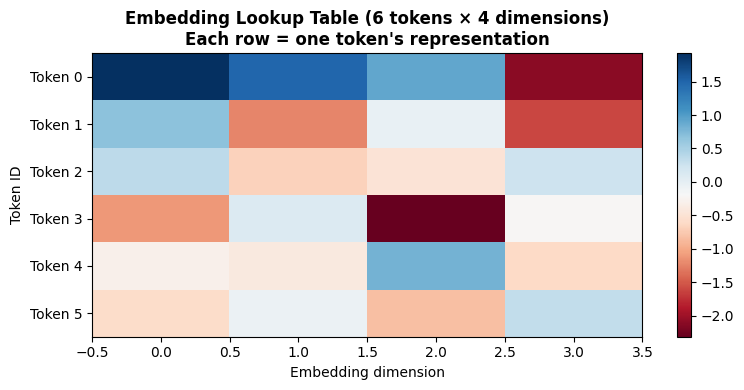

In [2]:
# Demonstrate the embedding lookup
vocab_size, embed_dim = 6, 4
emb = nn.Embedding(vocab_size, embed_dim)

token_id    = 3
looked_up   = emb(torch.tensor(token_id))

# Same result via one-hot @ weight matrix
one_hot_vec = torch.zeros(vocab_size)
one_hot_vec[token_id] = 1.0
manual      = one_hot_vec @ emb.weight

print(f"Token ID: {token_id}")
print(f"Embedding row {token_id}:   {emb.weight[token_id].detach().numpy().round(4)}")
print(f"nn.Embedding lookup:    {looked_up.detach().numpy().round(4)}")
print(f"one-hot @ W:            {manual.detach().numpy().round(4)}")
print(f"All three are the same: {torch.allclose(looked_up, manual)}")

# Visualise the full embedding table
plt.figure(figsize=(8, 4))
plt.imshow(emb.weight.detach().numpy(), cmap='RdBu', aspect='auto')
plt.colorbar()
plt.xlabel('Embedding dimension'); plt.ylabel('Token ID')
plt.title('Embedding Lookup Table (6 tokens × 4 dimensions)\nEach row = one token\'s representation', fontweight='bold')
plt.yticks(range(vocab_size), [f'Token {i}' for i in range(vocab_size)])
plt.tight_layout(); plt.show()

## 12.3 Learning Embeddings — Sentiment Example

The real power of embeddings is not that they're compact — it's that they're **learned**. When the network trains on a task, the embedding vectors are updated by backpropagation just like any other weights. Words that appear in similar contexts end up with similar vectors.

The pipeline for text classification:

```
"the movie was great"
        │
        ▼  Tokenise (split into words)
["the", "movie", "was", "great"]
        │
        ▼  Map to integer IDs
[4, 12, 18, 7]
        │
        ▼  Embedding lookup (each ID → dense vector)
[[0.21, -0.3, ...], [0.44, 0.1, ...], [-0.1, 0.8, ...], [0.9, 0.2, ...]]
        │
        ▼  Average all word vectors (mean pooling)
[0.38, 0.2, ...]  ← one vector representing the whole sentence
        │
        ▼  Linear classifier
     Positive / Negative / Neutral
```

Mean pooling (averaging all word vectors) is the simplest way to go from a sequence of word vectors to a single sentence vector. It discards word order but works surprisingly well for sentiment. More sophisticated models use attention (Transformers) to weight which words matter more.

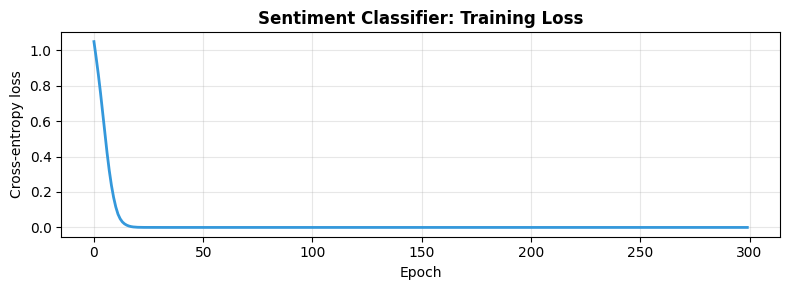


Predictions:
  ✓  'the movie was great                     ' → positive
  ✓  'i loved the film                        ' → positive
  ✓  'absolutely fantastic story              ' → positive
  ✓  'wonderful acting performance            ' → positive
  ✓  'the movie was terrible                  ' → negative
  ✓  'i hated this film                       ' → negative
  ✓  'boring and awful story                  ' → negative
  ✓  'worst movie ever seen                   ' → negative
  ✓  'it was okay i guess                     ' → neutral
  ✓  'not bad not great either                ' → neutral


In [3]:
# Build and train a sentiment classifier
sentences = [
    "the movie was great",        "i loved the film",
    "absolutely fantastic story", "wonderful acting performance",
    "the movie was terrible",     "i hated this film",
    "boring and awful story",     "worst movie ever seen",
    "it was okay i guess",        "not bad not great either",
]
labels = [1,1,1,1, 0,0,0,0, 2,2]  # 1=positive, 0=negative, 2=neutral

words    = sorted(set(w for s in sentences for w in s.split()))
word2idx = {w: i+1 for i,w in enumerate(words)}; word2idx['<PAD>'] = 0
vocab_size = len(word2idx) + 1

max_len = max(len(s.split()) for s in sentences)
encoded = torch.zeros(len(sentences), max_len, dtype=torch.long)
for i, s in enumerate(sentences):
    for j, w in enumerate(s.split()): encoded[i,j] = word2idx[w]
y = torch.tensor(labels)

class SentimentNet(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc        = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.ReLU(),
                                       nn.Linear(hidden_dim, n_classes))

    def forward(self, x):
        emb    = self.embedding(x)      # (batch, seq_len, embed_dim)
        pooled = emb.mean(dim=1)        # mean over words → (batch, embed_dim)
        return self.fc(pooled)

model     = SentimentNet(vocab_size=vocab_size, embed_dim=8, hidden_dim=16, n_classes=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

losses = []
for _ in range(300):
    optimizer.zero_grad()
    loss = criterion(model(encoded), y)
    loss.backward(); optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses, color='#3498DB', lw=2)
plt.title("Sentiment Classifier: Training Loss", fontweight='bold')
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

preds      = model(encoded).argmax(1)
labels_map = {0:'negative', 1:'positive', 2:'neutral'}
print("\nPredictions:")
for s, true, pred in zip(sentences, labels, preds.tolist()):
    status = '✓' if true == pred else '✗'
    print(f"  {status}  '{s:<40}' → {labels_map[pred]}")

## 12.4 Visualising Embeddings — Do Similar Words Cluster?

After training, the embedding vectors should encode meaning. We can't visualise 8-dimensional vectors directly, but we can project them to 2D using PCA — the same technique used to visualise any high-dimensional data.

If the model has learned anything about sentiment, positive words (great, loved, fantastic) should cluster together, negative words (terrible, hated, awful) should cluster together, and the two groups should be far apart in the embedding space.

This is a small toy example so the separation won't be perfect — but the pattern should be visible.

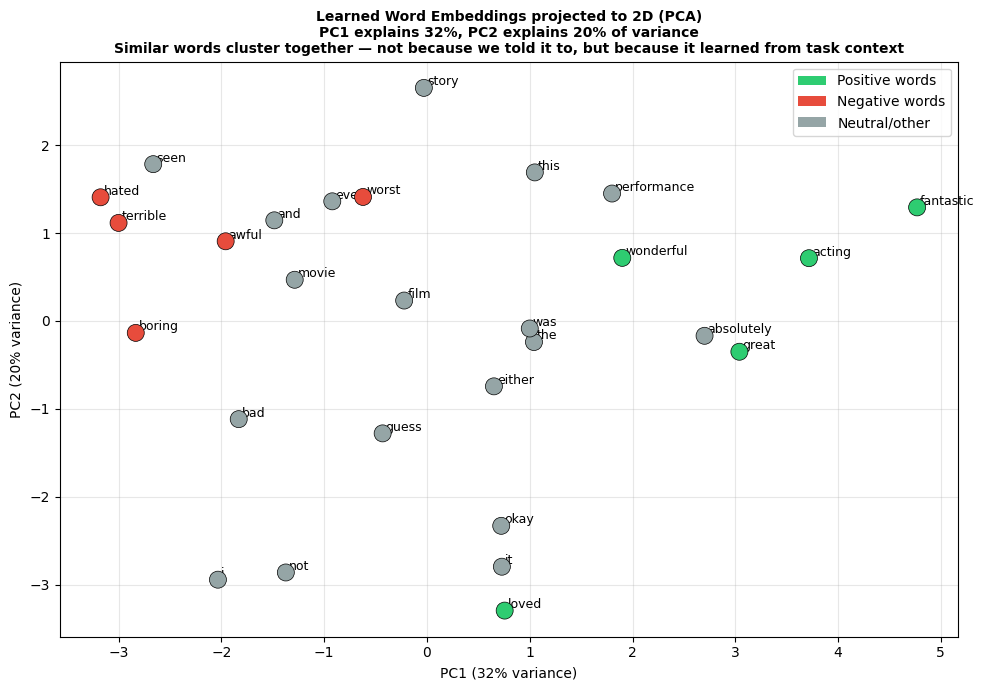

In [4]:
with torch.no_grad():
    all_ids  = torch.tensor([word2idx[w] for w in words])
    all_vecs = model.embedding(all_ids).numpy()

pca      = PCA(n_components=2)
vecs_2d  = pca.fit_transform(all_vecs)
var_exp  = pca.explained_variance_ratio_

pos_words = {'great','loved','fantastic','wonderful','acting'}
neg_words = {'terrible','hated','boring','awful','worst'}
colors    = ['#2ECC71' if w in pos_words else '#E74C3C' if w in neg_words
             else '#95A5A6' for w in words]

plt.figure(figsize=(10, 7))
plt.scatter(vecs_2d[:,0], vecs_2d[:,1], c=colors, s=150, zorder=5, edgecolors='k', lw=0.5)
for i, w in enumerate(words):
    plt.annotate(w, (vecs_2d[i,0]+0.03, vecs_2d[i,1]+0.03), fontsize=9)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor='#2ECC71', label='Positive words'),
    Patch(facecolor='#E74C3C', label='Negative words'),
    Patch(facecolor='#95A5A6', label='Neutral/other')
], loc='best')
plt.title(
    f"Learned Word Embeddings projected to 2D (PCA)\n"
    f"PC1 explains {var_exp[0]:.0%}, PC2 explains {var_exp[1]:.0%} of variance\n"
    "Similar words cluster together — not because we told it to, but because it learned from task context",
    fontsize=10, fontweight='bold')
plt.xlabel(f"PC1 ({var_exp[0]:.0%} variance)")
plt.ylabel(f"PC2 ({var_exp[1]:.0%} variance)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 12.5 Embeddings for Categories — Not Just Words

Embeddings work for **any discrete input**, not just words. This is one of the most underused techniques in tabular ML.

### Examples

| Use case | Discrete input | What an embedding learns |
|---|---|---|
| Recommendation | User IDs, Movie IDs | User taste profiles, movie genre representations |
| Time series | Day of week, Month, Hour | Weekend vs weekday patterns, seasonal patterns |
| E-commerce | Product categories | Category similarity for cross-sell |
| NLP | Words, subword tokens | Semantic meaning |
| Genomics | DNA base pairs | Biological sequence context |

### Why use embeddings instead of one-hot for tabular data?

Suppose you have a `city` feature with 5,000 unique cities. One-hot encoding adds 5,000 binary columns. An embedding of dimension 16 adds only 16 columns — but those 16 values carry learned geographic and demographic information (cities in the same region end up with similar embeddings). For high-cardinality categoricals, embeddings almost always outperform one-hot encoding.

A rough rule for embedding dimension: `min(50, (cardinality + 1) // 2)`. So 10 cities → dim 5; 1,000 cities → dim 50.

In [5]:
# Categorical embedding: day-of-week for time series
days      = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_emb   = nn.Embedding(num_embeddings=7, embedding_dim=4)
day_ids   = torch.arange(7)
day_vecs  = day_emb(day_ids)

print("Day-of-week embeddings (dim=4) — before training (random):")
for day, vec in zip(days, day_vecs.detach().numpy()):
    print(f"  {day}: {vec.round(3)}")

print()
print("After training on a sales prediction task, weekday embeddings")
print("(Mon–Fri) would cluster together, and weekend embeddings (Sat–Sun)")
print("would form a separate cluster — learned purely from sales patterns.")

# Show a recommendation system sketch
print("\n--- Recommendation System Sketch ---")
n_users, n_items, dim = 1000, 500, 32
user_emb = nn.Embedding(n_users, dim)
item_emb = nn.Embedding(n_items, dim)

user_ids = torch.tensor([42, 17, 99])
item_ids = torch.tensor([7,  233, 401])

u_vecs   = user_emb(user_ids)   # (3, 32)
i_vecs   = item_emb(item_ids)   # (3, 32)
scores   = (u_vecs * i_vecs).sum(dim=1)  # dot product = predicted affinity

print(f"User embedding shape:  {u_vecs.shape}  ({n_users} users, dim={dim})")
print(f"Item embedding shape:  {i_vecs.shape}  ({n_items} items, dim={dim})")
print(f"Predicted scores:      {scores.detach().numpy().round(3)}")
print(f"\nTotal parameters:  users {n_users*dim:,} + items {n_items*dim:,} = {(n_users+n_items)*dim:,}")
print(f"One-hot alternative: {n_users*n_items:,} parameters — {n_users*n_items/((n_users+n_items)*dim):.0f}x more")

Day-of-week embeddings (dim=4) — before training (random):
  Mon: [-1.517  0.206  0.272  0.061]
  Tue: [-1.177  1.622  0.851 -0.4  ]
  Wed: [-0.685  0.713  0.53  -0.91 ]
  Thu: [ 1.965 -1.177  1.189  0.216]
  Fri: [0.626 0.914 1.01  0.895]
  Sat: [ 0.518 -1.746  1.096  0.487]
  Sun: [ 0.367 -0.391  0.17  -0.87 ]

After training on a sales prediction task, weekday embeddings
(Mon–Fri) would cluster together, and weekend embeddings (Sat–Sun)
would form a separate cluster — learned purely from sales patterns.

--- Recommendation System Sketch ---
User embedding shape:  torch.Size([3, 32])  (1000 users, dim=32)
Item embedding shape:  torch.Size([3, 32])  (500 items, dim=32)
Predicted scores:      [-6.935  2.314 -2.896]

Total parameters:  users 32,000 + items 16,000 = 48,000
One-hot alternative: 500,000 parameters — 10x more


## 12.6 Pretrained Embeddings

Just as CNNs benefit from pretraining on ImageNet, NLP models benefit from pretrained word embeddings.

**Word2Vec** (Google, 2013) and **GloVe** (Stanford, 2014) are embeddings trained on billions of words from Wikipedia, news articles and books. They encode rich semantic relationships:

```
king - man + woman ≈ queen       (gender analogy)
Paris - France + Italy ≈ Rome    (capital analogy)
```

**Modern contextual embeddings** (BERT, GPT) go further — the embedding of a word depends on its surrounding context. "bank" in "river bank" and "bank account" gets different vectors. These are learned during pretraining on massive text corpora and can be fine-tuned on your specific task with very little data.

The key difference from what we built in this notebook: our embeddings are **task-specific** (trained only on 10 short sentences). Pretrained embeddings are **general-purpose** (trained on billions of tokens) and can be loaded and reused. In practice, for any NLP task, you would start from pretrained embeddings rather than random initialisation.